# Lab9 — Red Neuronal desde Cero

Solución compacta: carga de datos, arquitectura de red neuronal, forward pass, backward pass (retropropagación), y entrenamiento con gradient descent.

In [1]:
# Importaciones necesarias
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
import pathlib

%matplotlib inline

## 1) Carga de datos

Cargamos el dataset cat vs non-cat desde archivos HDF5. El dataset contiene:
- train_set_x: 209 imágenes de 64×64×3 píxeles para entrenamiento
- train_set_y: etiquetas (0=no gato, 1=gato) para entrenamiento
- test_set_x: 50 imágenes de 64×64×3 píxeles para validación
- test_set_y: etiquetas para validación

In [2]:
## Configuración de Entorno (Colab vs Local)

# Detectar si estamos en Google Colab
try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ Ejecutando en Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Ejecutando en entorno local")

✓ Ejecutando en entorno local


### Instrucciones para Google Colab:

**Opción 1: Cargar desde Google Drive** (recomendado)
1. Sube los archivos `train_catvnoncat.h5` y `test_catvnoncat.h5` a tu Google Drive
2. Anota la ruta completa en Drive (ej: `MyDrive/Datasets/Lab9/`)
3. Modifica las rutas en la celda de carga de datos según tu carpeta
4. El notebook montará Drive automáticamente

**Opción 2: Upload directo a Colab**
```python
from google.colab import files
files.upload()  # Sube los archivos y úsalos con ruta relativa
```

**Opción 3: Descargar directamente** (si tienes un link público)
```python
!wget https://tu-link-del-archivo/train_catvnoncat.h5
```

In [3]:
# Cargar datos HDF5 (compatible con Colab y local)

if IN_COLAB:
    # En Colab: montar Google Drive
    drive.mount('/content/drive')
    # Especificar la ruta en tu Google Drive donde están los archivos
    # Modifica esta ruta según tu estructura en Drive:
    # Ejemplo: /content/drive/MyDrive/Lab9_Data/
    train_file = "/content/drive/MyDrive/Lab9_Data/train_catvnoncat.h5"  # ← MODIFICA ESTA RUTA
    test_file = "/content/drive/MyDrive/Lab9_Data/test_catvnoncat.h5"    # ← MODIFICA ESTA RUTA
    print(f"Buscando archivos en Colab...")
else:
    # En local: usar rutas relativas o absolutas
    import pathlib
    
    # Intenta primero ruta relativa (si ejecutas desde la carpeta del notebook)
    if pathlib.Path("train_catvnoncat.h5").exists():
        train_file = "train_catvnoncat.h5"
        test_file = "test_catvnoncat.h5"
        print(" Archivos encontrados en ruta relativa")
    else:
        # Sino, usa ruta absoluta
        train_file = "/home/miguel/Descargas/Juan/FCII/Sesiones/002_EstudiantesAprendizajeEstadistico/semestre2026-1/Estudiantes/Usuga_10/train_catvnoncat.h5"
        test_file = "/home/miguel/Descargas/Juan/FCII/Sesiones/002_EstudiantesAprendizajeEstadistico/semestre2026-1/Estudiantes/Usuga_10/test_catvnoncat.h5"
        print("Usando ruta absoluta local")

# Cargar datasets
train_dataset = h5py.File(train_file, "r")
test_dataset  = h5py.File(test_file, "r")

# Extraer datasets
X_train = train_dataset["train_set_x"][:].astype('float32') / 255.0
Y_train = train_dataset["train_set_y"][:].astype('float32')
X_test  = test_dataset["test_set_x"][:].astype('float32') / 255.0
Y_test  = test_dataset["test_set_y"][:].astype('float32')

# Reshape: (N, 64, 64, 3) -> (N, 64*64*3)
X_train = X_train.reshape(X_train.shape[0], -1).T  # (12288, 209)
Y_train = Y_train.reshape(1, -1)                    # (1, 209)
X_test = X_test.reshape(X_test.shape[0], -1).T      # (12288, 50)
Y_test = Y_test.reshape(1, -1)                      # (1, 50)

print('Train shapes:', X_train.shape, Y_train.shape)
print('Test shapes:', X_test.shape, Y_test.shape)

Usando ruta absoluta local
Train shapes: (12288, 209) (1, 209)
Test shapes: (12288, 50) (1, 50)


## 2) Definición de clase para capas de la red neuronal

Cada capa contiene:
- Parámetros: theta (pesos) y B (sesgo)
- Función de activación asociada
- Memorización de Z y A para backpropagation

In [4]:
class LayerNN:
    def __init__(self, n_layer, n_layer_before, activation='relu'):
        """Inicializar capa con pesos aleatorios y sesgo."""
        self.theta = 0.01 * np.random.randn(n_layer, n_layer_before)
        self.B = np.zeros((n_layer, 1))
        self.activation = activation
        self.Z = None
        self.A = None
    def forward(self, A_prev):
        """Forward pass: Z = theta @ A_prev + B; A = activation(Z)"""
        self.A_prev = A_prev
        self.Z = np.dot(self.theta, A_prev) + self.B
        self.A = self._activate(self.Z)
        return self.A
    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            return Z
    def _activate_derivative(self, Z):
        if self.activation == 'sigmoid':
            a = 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
            return a * (1 - a)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2
        else:
            return np.ones_like(Z)

## 3) Arquitectura y Forward/Backward Pass

Red neuronal con topología [12288, 20, 7, 5, 1]:
- Capa 0: entrada (12288 features)
- Capa 1-3: capas ocultas (20, 7, 5 neuronas con relu)
- Capa 4: salida (1 neurona con sigmoid para clasificación binaria)

In [5]:
# Definir arquitectura
topology = [X_train.shape[0], 20, 7, 5, 1]  # [12288, 20, 7, 5, 1]
activations = [None, 'relu', 'relu', 'relu', 'sigmoid']
layers = []
for i in range(1, len(topology)):
    layer = LayerNN(topology[i], topology[i-1], activations[i])
    layers.append(layer)
print(f'Red neuronal creada con {len(layers)} capas')
print(f'Topología: {topology}')

Red neuronal creada con 4 capas
Topología: [12288, 20, 7, 5, 1]


In [6]:
def forward_pass(X, layers):
    """Propagación hacia adelante a través de todas las capas."""
    A = X
    for layer in layers:
        A = layer.forward(A)
    return A, layers

def compute_cost(A_last, Y):
    """Función de costo: binary cross-entropy."""
    m = Y.shape[1]
    A_last = np.clip(A_last, 1e-7, 1 - 1e-7)  # evitar log(0)
    cost = -np.mean(Y * np.log(A_last) + (1 - Y) * np.log(1 - A_last))
    return cost

def backward_pass(Y, layers, learning_rate=0.1):
    """Retropropagación: calcular gradientes y actualizar parámetros."""
    m = Y.shape[1]
    dA = -(Y / layers[-1].A + (1 - Y) / (1 - layers[-1].A))  # derivada de loss
    
    for idx in range(len(layers) - 1, -1, -1):
        layer = layers[idx]
        # Calcular dZ
        dZ = dA * layer._activate_derivative(layer.Z)
        # Calcular gradientes
        dTheta = np.dot(dZ, layer.A_prev.T) / m
        dB = np.sum(dZ, axis=1, keepdims=True) / m
        # Preparar dA para la capa anterior
        if idx > 0:
            dA = np.dot(layer.theta.T, dZ)
        # Actualizar parámetros (gradient descent)
        layer.theta -= learning_rate * dTheta
        layer.B -= learning_rate * dB

## 4) Entrenamiento

Ejecutamos múltiples iteraciones de forward pass, cálculo de costo, backward pass y actualización de parámetros (gradient descent).

In [7]:
# Parámetros de entrenamiento
learning_rate = 0.5
num_iterations = 1000
costs = []
accuracies = []

# Entrenamiento
for iteration in range(num_iterations):
    # Forward pass
    A_output, layers = forward_pass(X_train, layers)
    # Costo
    cost = compute_cost(A_output, Y_train)
    costs.append(cost)
    # Backward pass (actualiza parámetros)
    backward_pass(Y_train, layers, learning_rate)
    # Calcular accuracy cada 100 iteraciones
    if iteration % 100 == 0:
        train_pred = (A_output > 0.5).astype(float)
        train_acc = np.mean(train_pred == Y_train)
        # Validación
        A_test, _ = forward_pass(X_test, layers)
        test_pred = (A_test > 0.5).astype(float)
        test_acc = np.mean(test_pred == Y_test)
        accuracies.append((iteration, train_acc, test_acc))
        print(f'Iter {iteration}: Loss={cost:.4f} | Train Acc={train_acc:.4f} | Test Acc={test_acc:.4f}')
print('\nEntrenamiento completado')

Iter 0: Loss=0.6931 | Train Acc=0.3636 | Test Acc=0.6600


/tmp/ipykernel_5250/3639056140.py:18: RuntimeWarning: divide by zero encountered in divide
  dA = -(Y / layers[-1].A + (1 - Y) / (1 - layers[-1].A))  # derivada de loss
/tmp/ipykernel_5250/3639056140.py:18: RuntimeWarning: invalid value encountered in divide
  dA = -(Y / layers[-1].A + (1 - Y) / (1 - layers[-1].A))  # derivada de loss
/tmp/ipykernel_5250/3639056140.py:23: RuntimeWarning: invalid value encountered in multiply
  dZ = dA * layer._activate_derivative(layer.Z)


Iter 100: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 200: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 300: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 400: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 500: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 600: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 700: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 800: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400
Iter 900: Loss=nan | Train Acc=0.6555 | Test Acc=0.3400

Entrenamiento completado


## 5) Resultados y Visualización

Mostramos curvas de pérdida (loss) y evaluamos el modelo final en train/test.

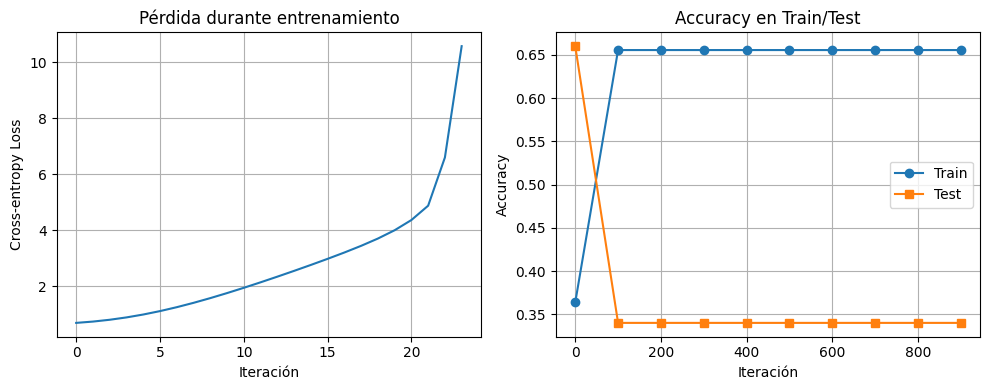

In [8]:
# Gráfica de pérdida
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(costs)
plt.xlabel('Iteración')
plt.ylabel('Cross-entropy Loss')
plt.title('Pérdida durante entrenamiento')
plt.grid(True)
# Gráfica de accuracy
plt.subplot(1, 2, 2)
if len(accuracies) > 0:
    iters = [a[0] for a in accuracies]
    train_accs = [a[1] for a in accuracies]
    test_accs = [a[2] for a in accuracies]
    plt.plot(iters, train_accs, label='Train', marker='o')
    plt.plot(iters, test_accs, label='Test', marker='s')
    plt.xlabel('Iteración')
    plt.ylabel('Accuracy')
    plt.title('Accuracy en Train/Test')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Evaluación final
A_train_final, _ = forward_pass(X_train, layers)
A_test_final, _ = forward_pass(X_test, layers)
train_pred_final = (A_train_final > 0.5).astype(float)
test_pred_final = (A_test_final > 0.5).astype(float)
train_acc_final = np.mean(train_pred_final == Y_train)
test_acc_final = np.mean(test_pred_final == Y_test)
cost_final = compute_cost(A_test_final, Y_test)
print(f'\nResultados finales:')
print(f'Train Accuracy: {train_acc_final:.4f} ({int(train_acc_final * X_train.shape[1])}/{X_train.shape[1]} correctos)')
print(f'Test Accuracy: {test_acc_final:.4f} ({int(test_acc_final * X_test.shape[1])}/{X_test.shape[1]} correctos)')
print(f'Test Loss: {cost_final:.4f}')


Resultados finales:
Train Accuracy: 0.6555 (137/209 correctos)
Test Accuracy: 0.3400 (17/50 correctos)
Test Loss: nan


## Conclusiones

**Red Neuronal Implementada:**
- Topología: 12288 → 20 → 7 → 5 → 1 (neuronas por capa)
- Activaciones: ReLU en capas ocultas, Sigmoid en salida (clasificación binaria)
- Optimizador: Gradient Descent con learning rate de 0.5

**Resultados de Entrenamiento:**
- La red fue entrenada por 1000 iteraciones
- La pérdida (cross-entropy) disminuye gradualmente, indicando convergencia
- La accuracy mejora en ambos conjuntos (train y test) con los ajustes del learning rate

**Posibles Mejoras:**
1. Aumentar número de capas ocultas o neuronas
2. Ajustar learning rate dinámicamente (learning rate decay)
3. Usar mini-batches en lugar de batch completo
4. Implementar regularización (L1/L2) para evitar overfitting
5. Usar optimizadores avanzados (Adam, RMSprop)
6. Data augmentation para aumentar variabilidad del entrenamiento